In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_validate
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [2]:
df = pd.read_csv("salary_dataset.csv")

In [3]:
X = df[["YearsExperience"]]
y = df["Salary"]

In [4]:
df.head()

,YearsExperience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0
4,2.3,39892.0


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
lr = LinearRegression()
tree = DecisionTreeRegressor(max_depth=3, random_state=42)

In [7]:
cv_lr = cross_validate(
    lr,
    X_train,
    y_train,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

In [8]:
cv_tree = cross_validate(
    tree,
    X_train,
    y_train,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

In [9]:
lr_rmse = -np.mean(cv_lr["test_score"])
tree_rmse = -np.mean(cv_tree["test_score"])

print("Linear Regression RMSE:", round(lr_rmse, 2))
print("Decision Tree RMSE:", round(tree_rmse, 2))

Linear Regression RMSE: 5293.2
Decision Tree RMSE: 6193.4


In [10]:
best_model = lr if lr_rmse < tree_rmse else tree


In [11]:
best_model.fit(X_train, y_train)

LinearRegression()

In [12]:
y_pred = best_model.predict(X_test)


In [13]:
test_rmse = mean_squared_error(y_test, y_pred) ** 0.5
print("Test RMSE:", round(test_rmse, 2))

Test RMSE: 7059.04


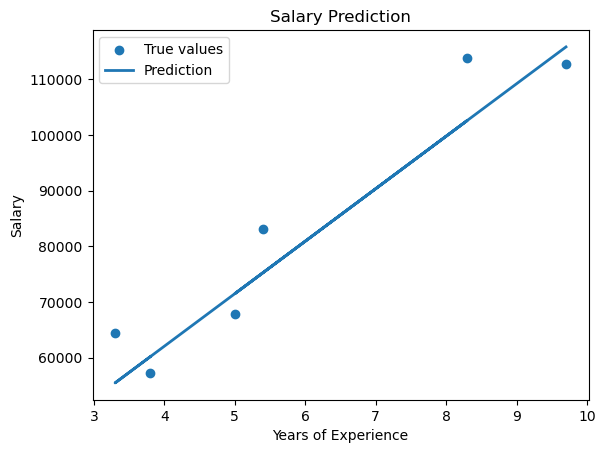

In [14]:
import matplotlib.pyplot as plt

plt.scatter(X_test, y_test, label="True values")
plt.plot(X_test, y_pred, linewidth=2, label="Prediction")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Salary Prediction")
plt.legend()
plt.show()